In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

In [2]:
df = pd.read_csv("retail_store_inventory_cleaned.csv")

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring
73099,2024-01-01,S005,P0020,Groceries,East,117,6,165,2.33,78.39,20,Rainy,1,79.52,Spring


In [5]:
print("Rows and Columns :", df.shape)

Rows and Columns : (73100, 15)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [7]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [8]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

#Histogram of sales

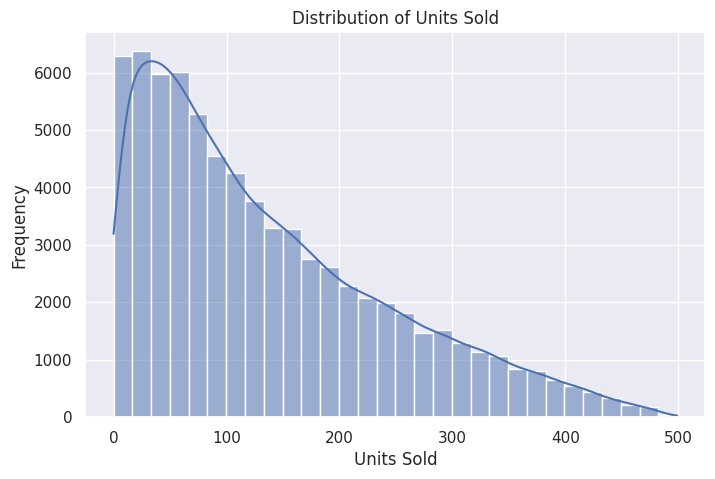

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Units Sold"], bins=30, kde=True)

plt.title("Distribution of Units Sold")

plt.xlabel("Units Sold")

plt.ylabel("Frequency")

plt.show()

#Histogram of  inventory

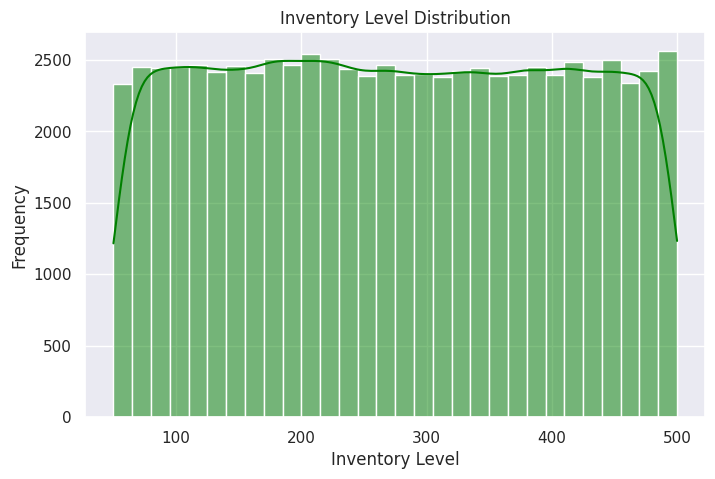

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Inventory Level"], bins=30, color="green", kde=True)

plt.title("Inventory Level Distribution")

plt.xlabel("Inventory Level")

plt.ylabel("Frequency")

plt.show()

#sales Box Plot

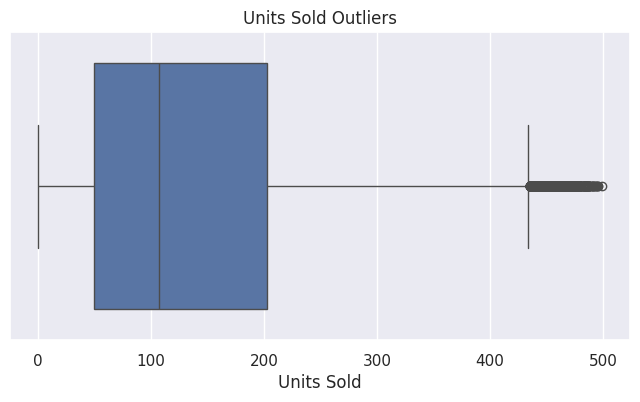

In [11]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Units Sold"])

plt.title("Units Sold Outliers")

plt.show()

#Top 10 Products by Sales

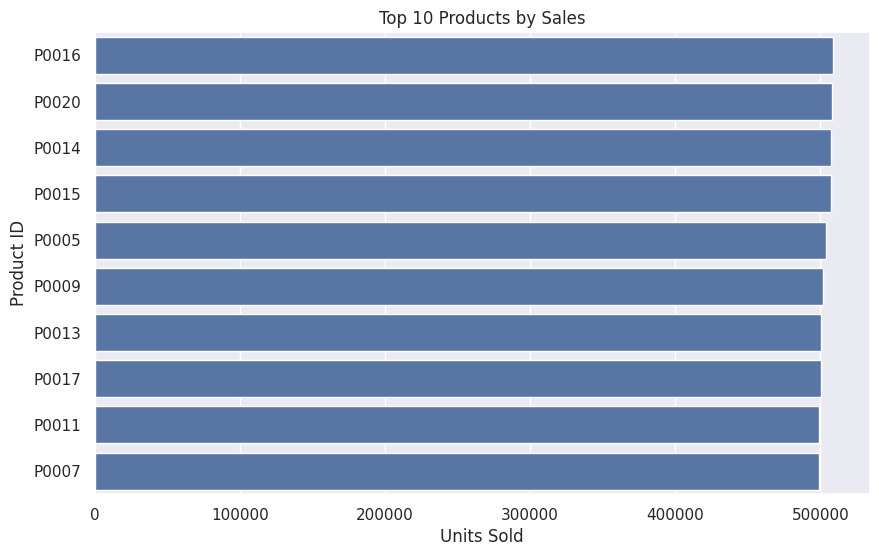

In [12]:
top_products = (
    df.groupby("Product ID")["Units Sold"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Units Sold")

plt.ylabel("Product ID")

plt.show()

Top 10 Products by Inventory

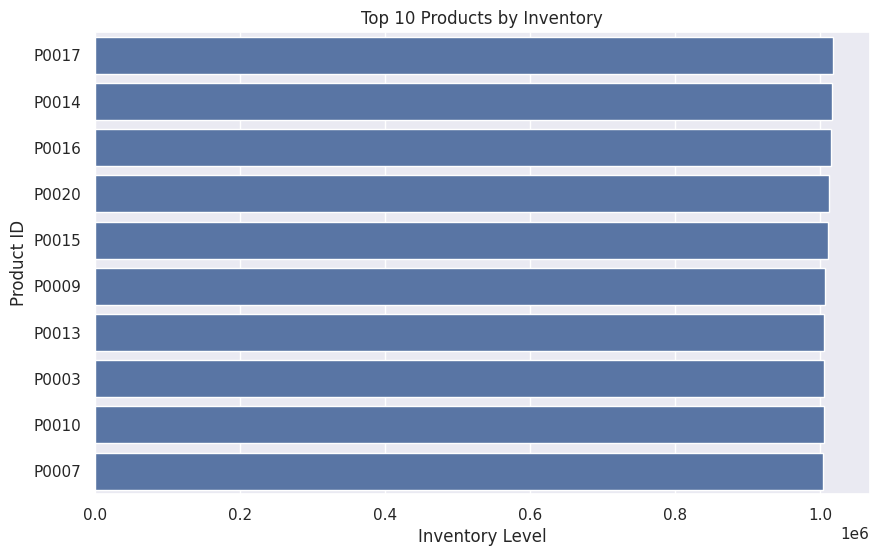

In [13]:
inventory = (
    df.groupby("Product ID")["Inventory Level"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=inventory.values,
    y=inventory.index,
)

plt.title("Top 10 Products by Inventory")

plt.xlabel("Inventory Level")

plt.ylabel("Product ID")

plt.show()

#Product Frequency

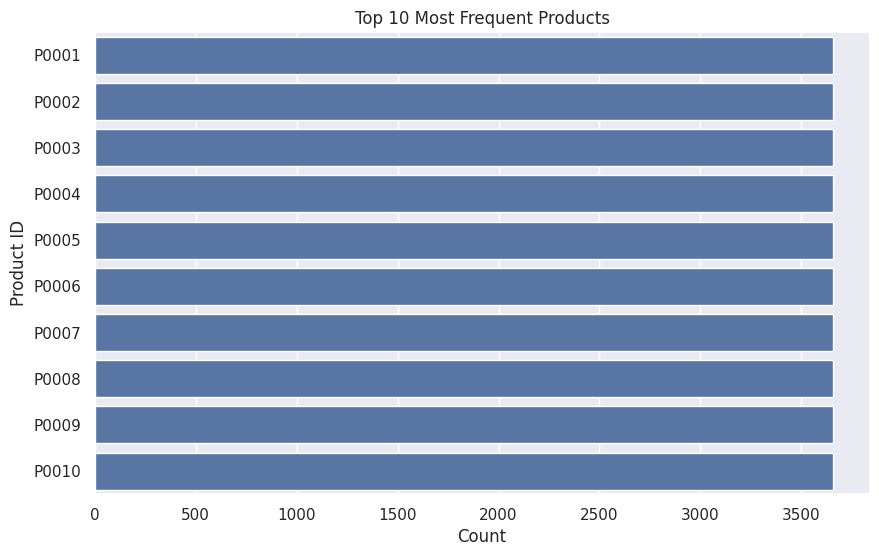

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="Product ID",
    data=df,
    order=df["Product ID"].value_counts().head(10).index
)

plt.title("Top 10 Most Frequent Products")

plt.xlabel("Count")

plt.ylabel("Product ID")

plt.show()

#Category-wise Sales

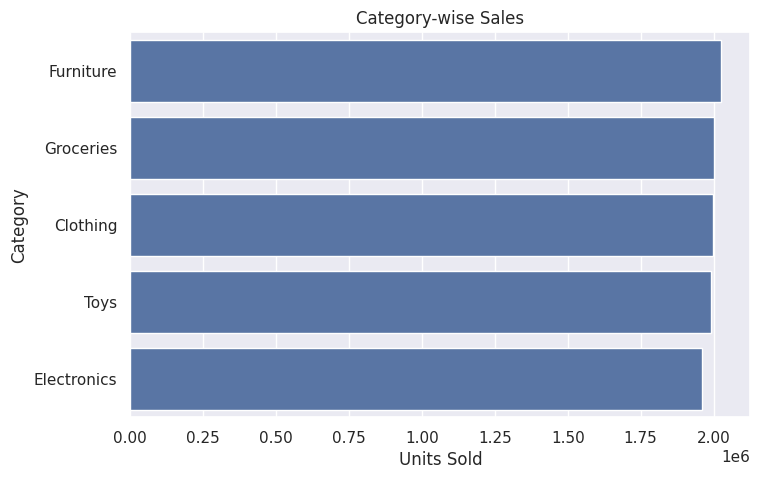

In [15]:
category_sales = (
    df.groupby("Category")["Units Sold"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Category-wise Sales")

plt.xlabel("Units Sold")

plt.ylabel("Category")

plt.show()

In [16]:
df["Date"] = pd.to_datetime(df["Date"])

#DAily Sales Trend

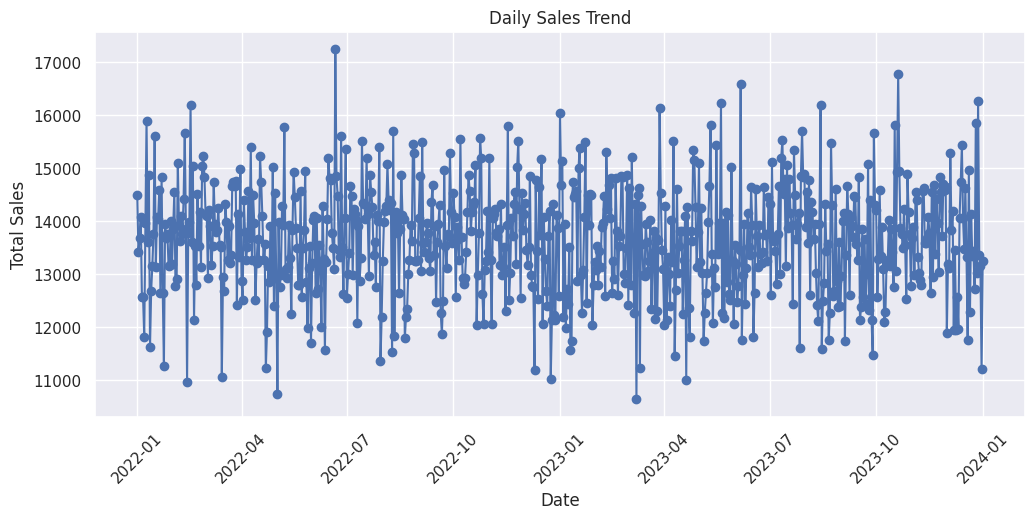

In [17]:
daily_sales = df.groupby("Date")["Units Sold"].sum()
plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values, marker='o')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#Monthly Sales Trend

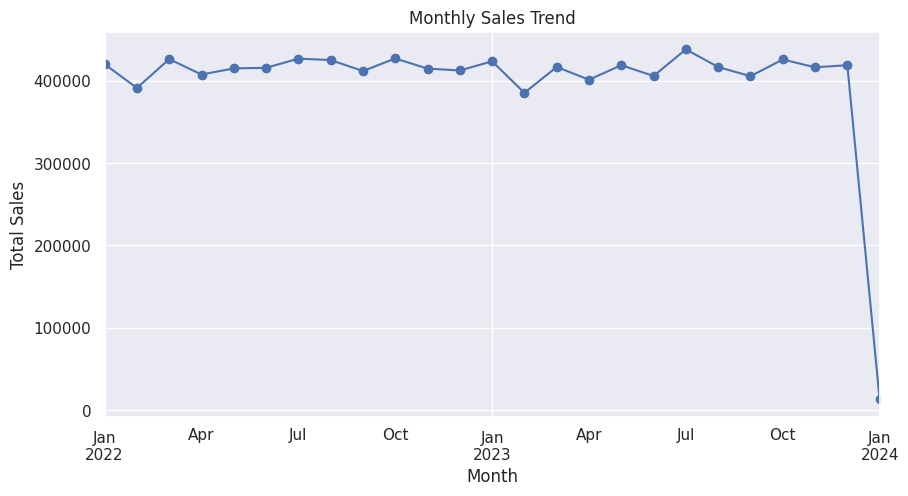

In [18]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Units Sold"].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

#Weekly Sales Trend

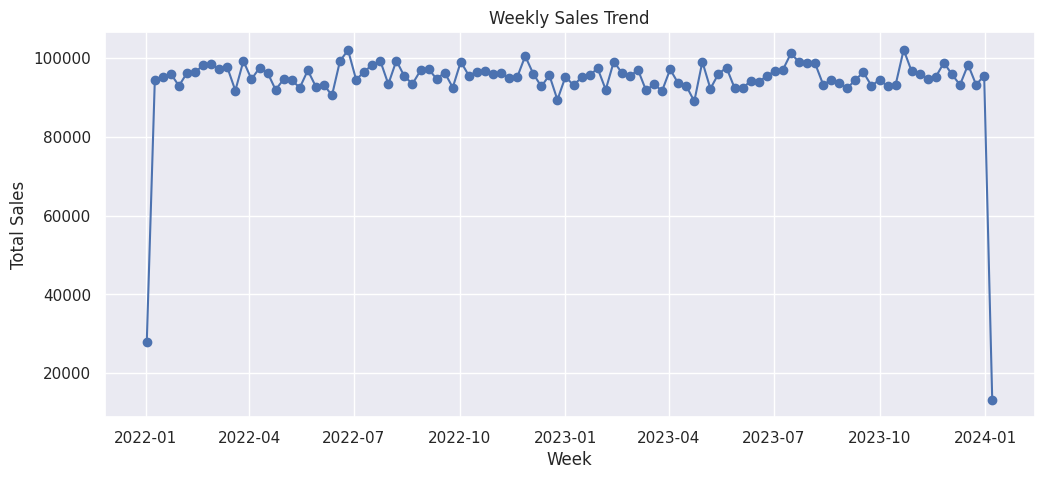

In [19]:
weekly_sales = df.groupby(pd.Grouper(key='Date', freq='W'))['Units Sold'].sum()
plt.figure(figsize=(12,5))
plt.plot(
    weekly_sales.index,
    weekly_sales.values,
    marker='o'
)
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

#Monthly order count

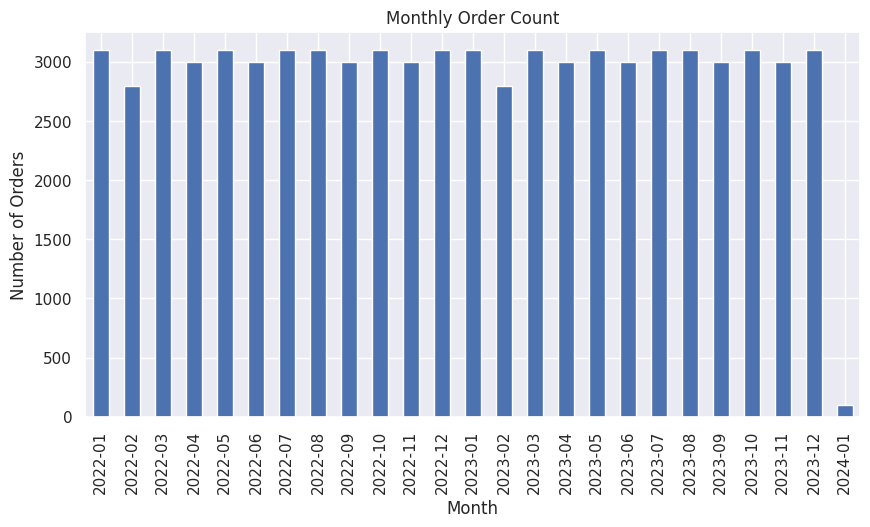

In [20]:
monthly_orders = df.groupby("Month").size()
plt.figure(figsize=(10,5))
monthly_orders.plot(kind="bar")
plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

#Warehouse wise sales

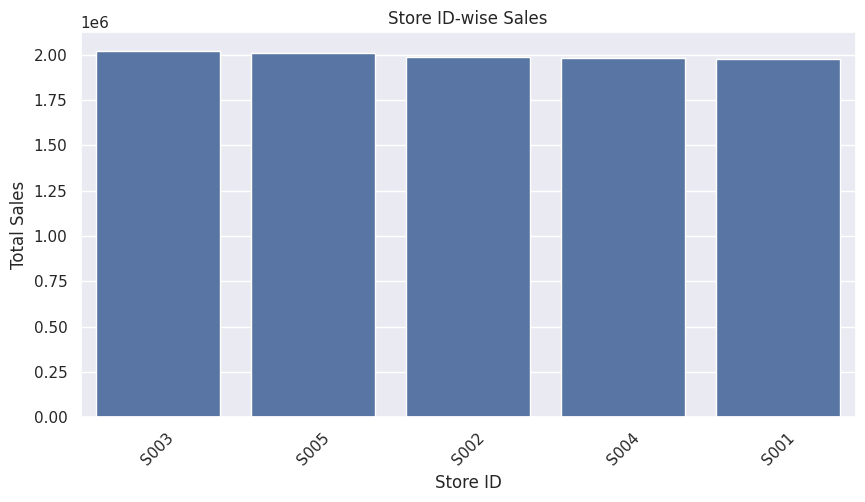

In [21]:
warehouse_sales = (
    df.groupby("Store ID")["Units Sold"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))

sns.barplot(
    x=warehouse_sales.index,
    y=warehouse_sales.values
)
plt.title("Store ID-wise Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

#Warehouse wise inventory

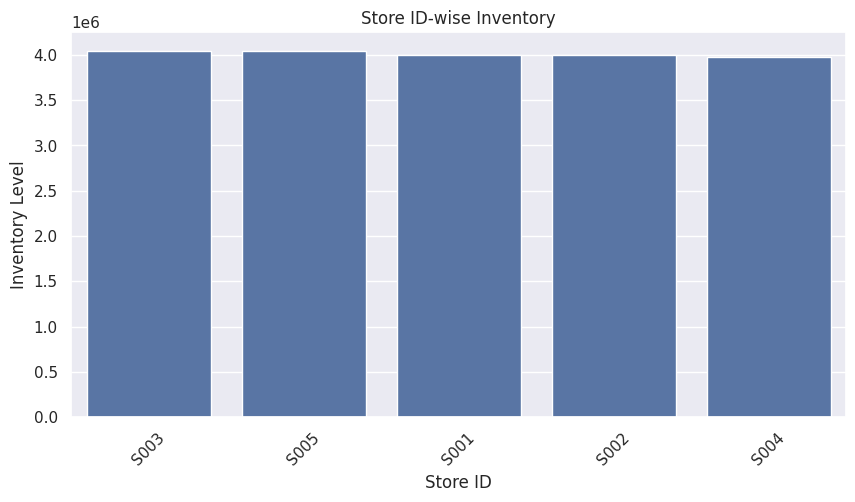

In [22]:
warehouse_inventory = (
    df.groupby("Store ID")["Inventory Level"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=warehouse_inventory.index,
    y=warehouse_inventory.values
)
plt.title("Store ID-wise Inventory")
plt.xlabel("Store ID")
plt.ylabel("Inventory Level")
plt.xticks(rotation=45)
plt.show()

#Inventory vs Sales

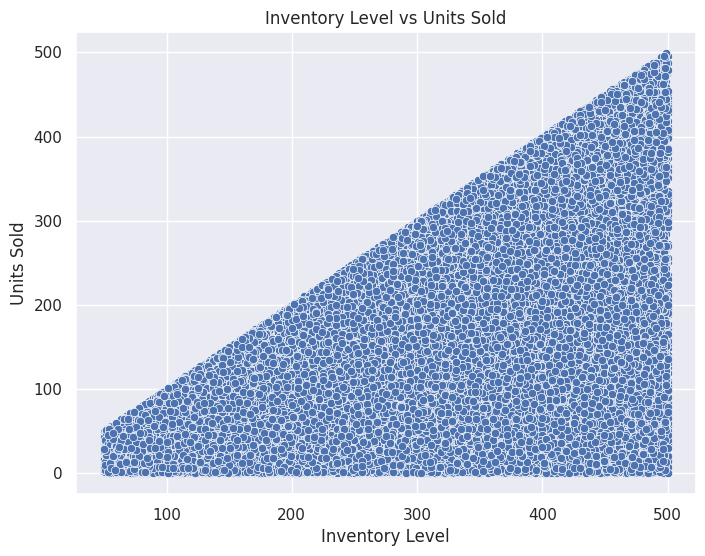

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Inventory Level",
    y="Units Sold"
)
plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.show()

#Correlation Heatmap

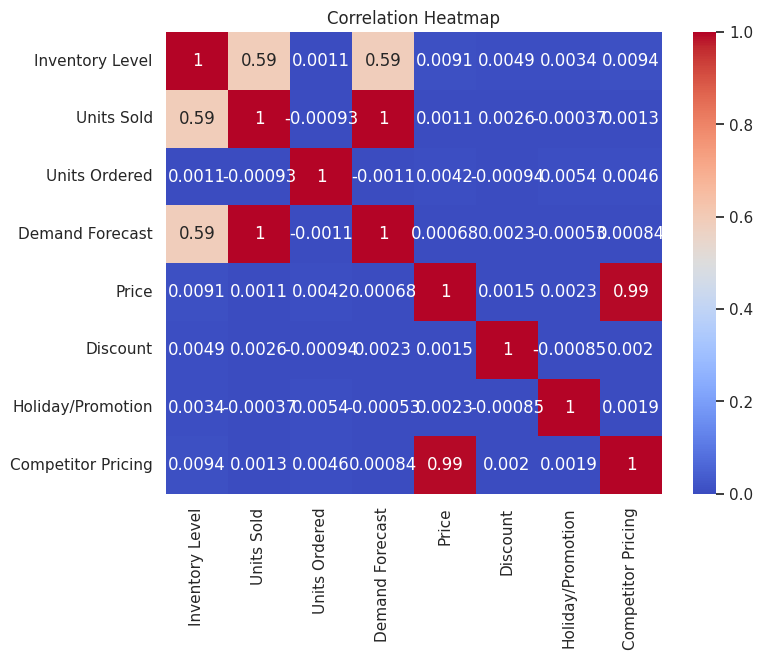

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

#Sales Outlier Detection

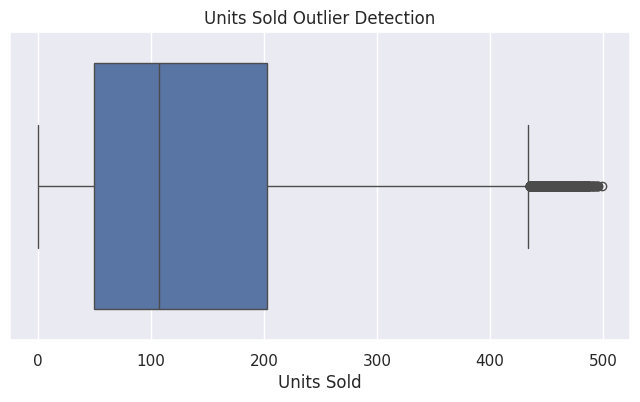

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"])
plt.title("Units Sold Outlier Detection")
plt.show()

In [26]:
df["Units Sold"].describe()

,Units Sold
count,73100.000000
mean,136.464870
std,108.919406
min,0.000000
25%,49.000000
50%,107.000000
75%,203.000000
max,499.000000


#Check sale distribution

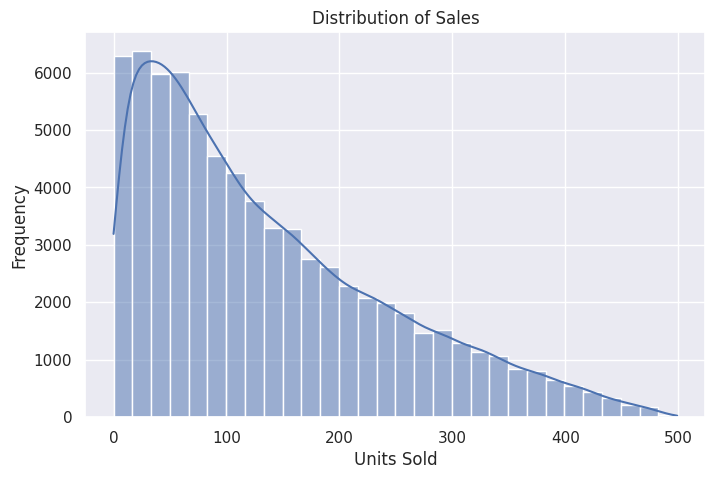

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["Units Sold"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

#Sales Box-Plot

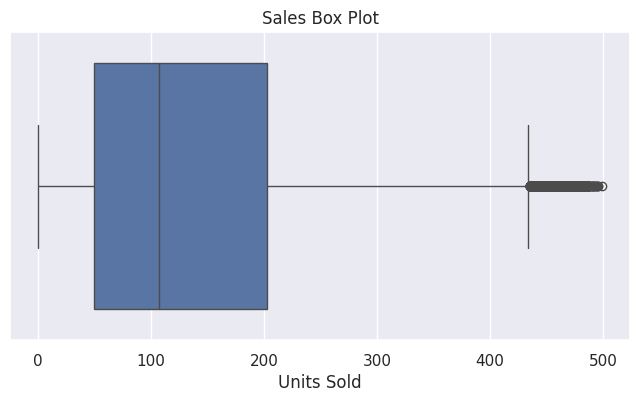

In [28]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"])
plt.title("Sales Box Plot")
plt.show()

#Density plot

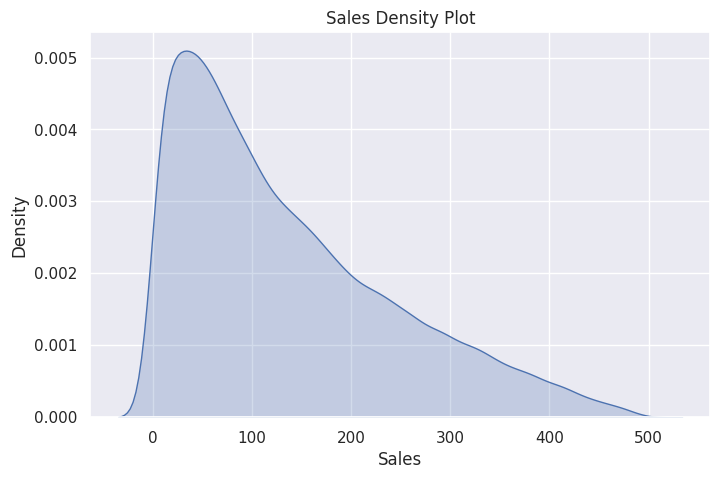

In [29]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Units Sold"], fill=True)
plt.title("Sales Density Plot")
plt.xlabel("Sales")
plt.show()

#Distribution with Mean Line

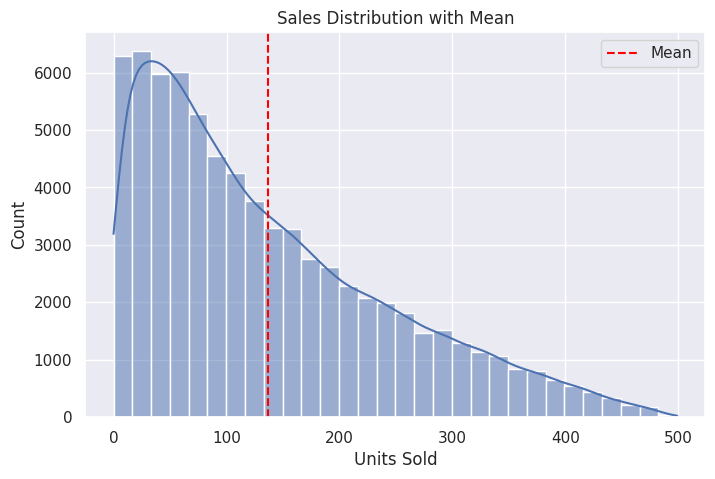

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.axvline(df["Units Sold"].mean(),
            color="red",
            linestyle="--",
            label="Mean")
plt.legend()
plt.title("Sales Distribution with Mean")
plt.show()

In [31]:
Q1 = df["Units Sold"].quantile(0.25)
Q3 = df["Units Sold"].quantile(0.75)
IQR = Q3 - Q1
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

Q1 : 49.0
Q3 : 203.0
IQR : 154.0


In [32]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Lower Bound : -182.0
Upper Bound : 434.0


In [33]:
iqr_anomalies = df[
    (df["Units Sold"] < lower_bound) |
    (df["Units Sold"] > upper_bound)
]
print("Total IQR Anomalies :", len(iqr_anomalies))
iqr_anomalies.head()

Total IQR Anomalies : 715


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Month
102,2022-01-02,S001,P0003,Clothing,South,488,464,163,463.12,70.99,10,Snowy,0,72.93,Summer,2022-01
138,2022-01-02,S002,P0019,Toys,East,492,479,132,469.74,79.11,0,Cloudy,0,80.06,Winter,2022-01
195,2022-01-02,S005,P0016,Groceries,East,487,437,106,432.86,43.64,15,Cloudy,1,39.13,Autumn,2022-01
322,2022-01-04,S002,P0003,Toys,North,493,448,113,459.44,41.55,15,Rainy,0,44.02,Winter,2022-01
554,2022-01-06,S003,P0015,Furniture,North,490,476,53,478.76,20.66,0,Rainy,1,16.87,Winter,2022-01


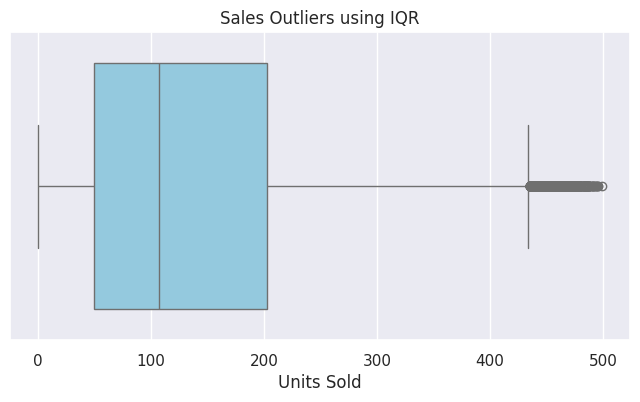

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"], color="skyblue")
plt.title("Sales Outliers using IQR")
plt.show()

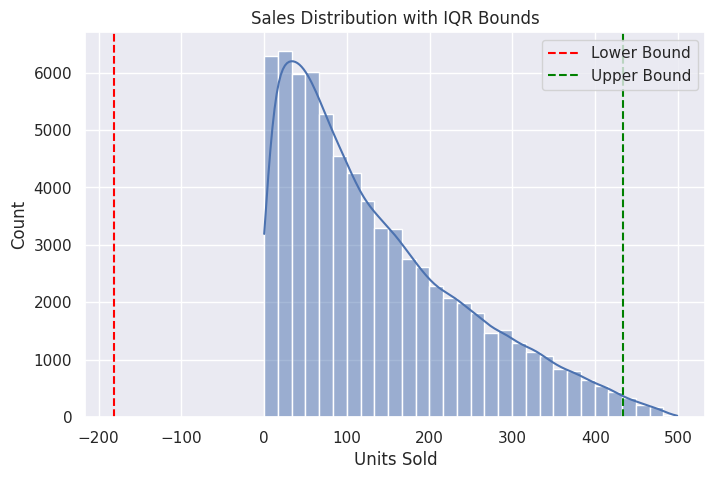

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.axvline(lower_bound, color="red", linestyle="--", label="Lower Bound")
plt.axvline(upper_bound, color="green", linestyle="--", label="Upper Bound")
plt.legend()
plt.title("Sales Distribution with IQR Bounds")
plt.show()

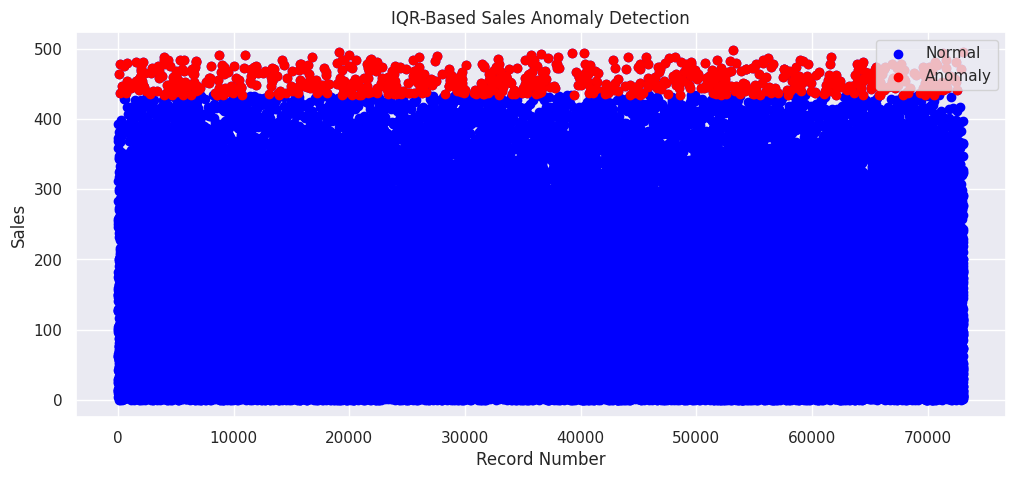

In [36]:
plt.figure(figsize=(12,5))
plt.scatter(df.index,
            df["Units Sold"],
            color="blue",
            label="Normal")
plt.scatter(iqr_anomalies.index,
            iqr_anomalies["Units Sold"],
            color="red",
            label="Anomaly")
plt.title("IQR-Based Sales Anomaly Detection")
plt.xlabel("Record Number")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [38]:
mean_sales = df["Units Sold"].mean()
std_sales = df["Units Sold"].std()
df["Z_score"] = (df["Units Sold"] - mean_sales) / std_sales
anomalies = df[abs(df["Z_score"]) > 3]

print("Z-Score Anomalies :", len(anomalies))
print("IQR Anomalies :", len(iqr_anomalies))

Z-Score Anomalies : 236
IQR Anomalies : 715


#Bar-Chart

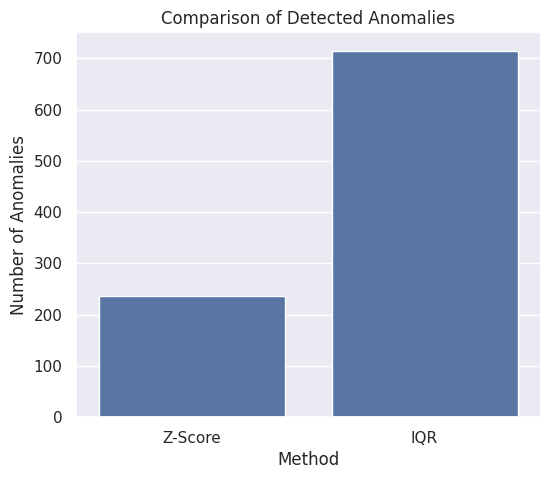

In [39]:
mean_sales = df["Units Sold"].mean()
std_sales = df["Units Sold"].std()
df["Z_score"] = (df["Units Sold"] - mean_sales) / std_sales
anomalies = df[abs(df["Z_score"]) > 3]

methods = ["Z-Score", "IQR"]
counts = [len(anomalies), len(iqr_anomalies)]
plt.figure(figsize=(6,5))
sns.barplot(x=methods, y=counts)
plt.title("Comparison of Detected Anomalies")
plt.xlabel("Method")
plt.ylabel("Number of Anomalies")
plt.show()

#Scatter plot

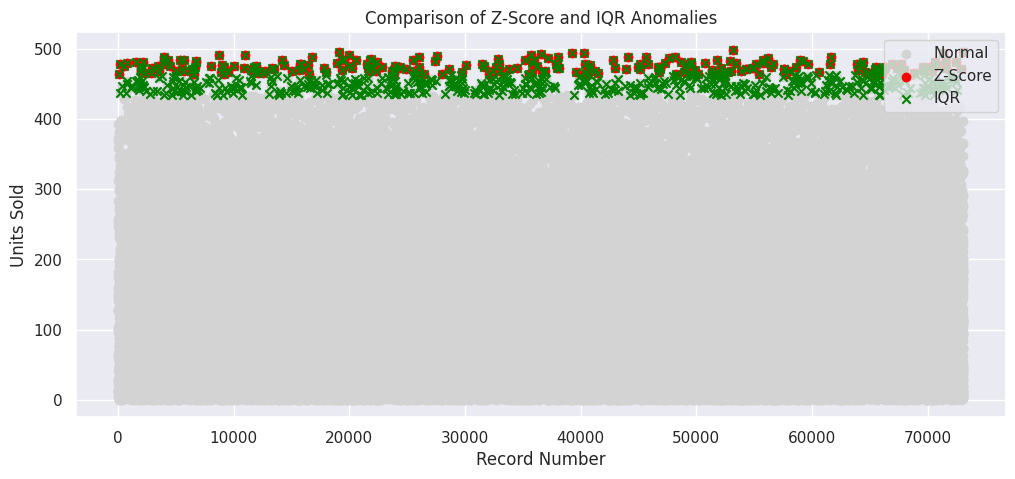

In [40]:
plt.figure(figsize=(12,5))
plt.scatter(df.index,
            df["Units Sold"],
            color="lightgray",
            label="Normal")
plt.scatter(anomalies.index,
            anomalies["Units Sold"],
            color="red",
            label="Z-Score")
plt.scatter(iqr_anomalies.index,
            iqr_anomalies["Units Sold"],
            color="green",
            marker="x",
            label="IQR")
plt.title("Comparison of Z-Score and IQR Anomalies")
plt.xlabel("Record Number")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

#Box-Plot

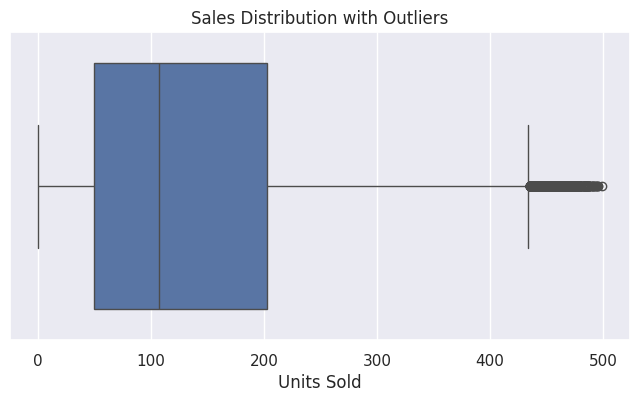

In [41]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"])
plt.title("Sales Distribution with Outliers")
plt.show()

#Histogram

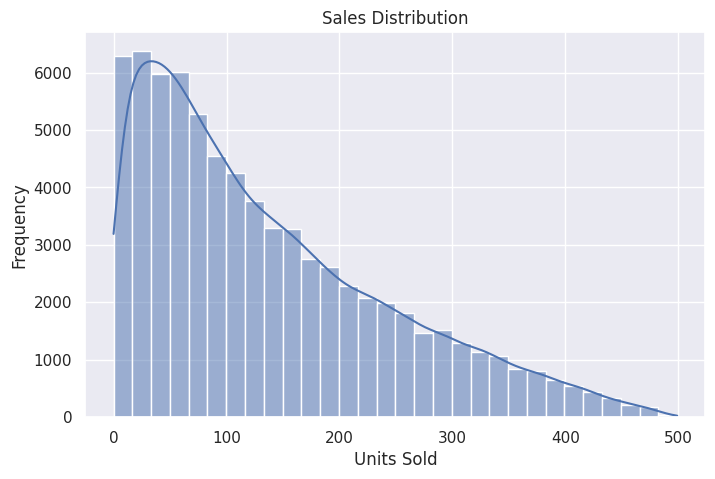

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

#Sales trend with Z-score Anomalies

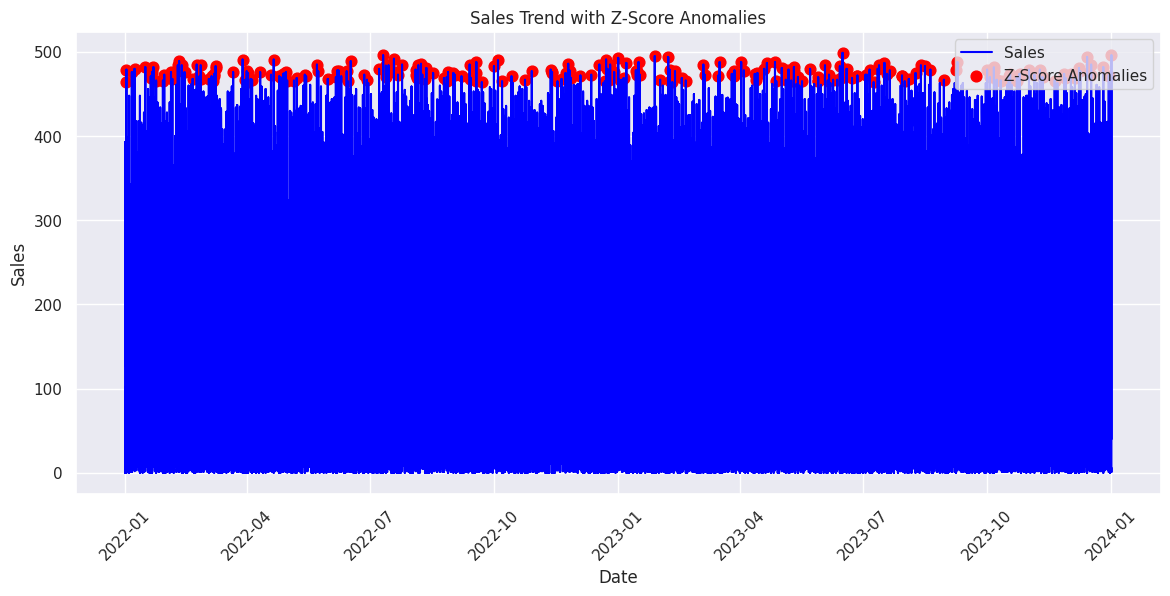

In [44]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Units Sold"], label="Sales", color="blue")
plt.scatter(
    anomalies["Date"],
    anomalies["Units Sold"],
    color="red",
    label="Z-Score Anomalies",
    s=60
)
plt.title("Sales Trend with Z-Score Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#Sales trend with IQR Anomalies

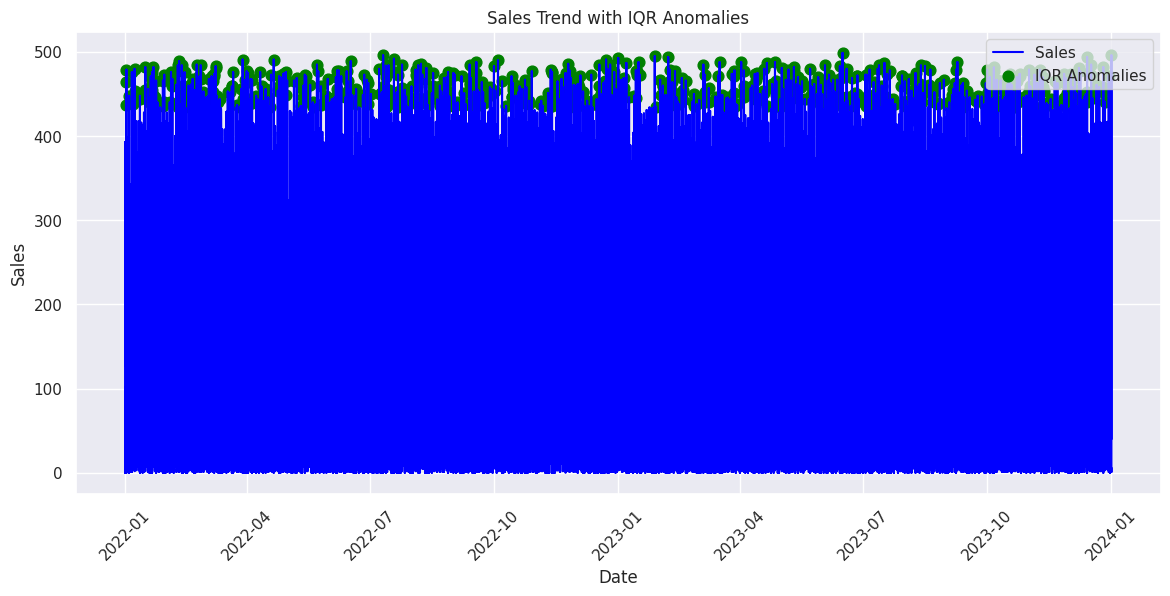

In [46]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Units Sold"], label="Sales", color="blue")
plt.scatter(
    iqr_anomalies["Date"],
    iqr_anomalies["Units Sold"],
    color="green",
    label="IQR Anomalies",
    s=60
)
plt.title("Sales Trend with IQR Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Monthly anomaly count

/tmp/ipykernel_849/1028101123.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["Month"] = pd.to_datetime(anomalies["Date"]).dt.to_period("M")


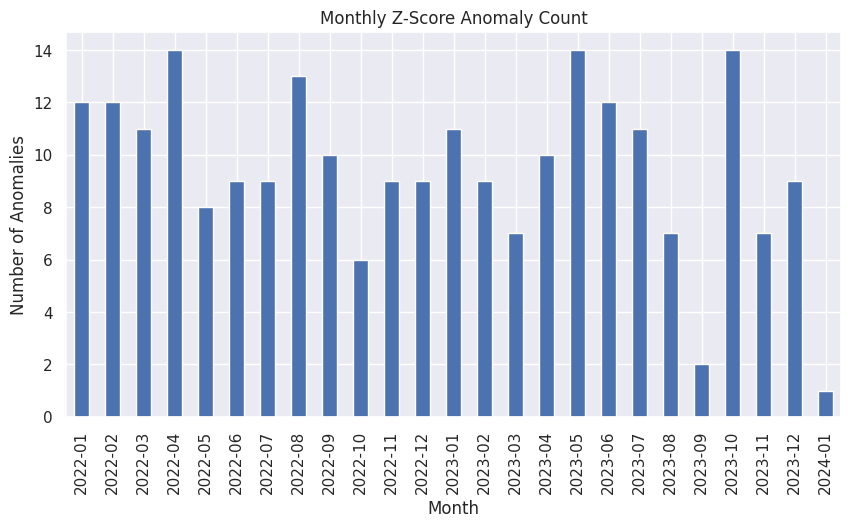

In [47]:
df["Month"] = pd.to_datetime(df["Date"]).dt.to_period("M")
anomalies["Month"] = pd.to_datetime(anomalies["Date"]).dt.to_period("M")
monthly_anomalies = anomalies.groupby("Month").size()
plt.figure(figsize=(10,5))
monthly_anomalies.plot(kind="bar")
plt.title("Monthly Z-Score Anomaly Count")
plt.xlabel("Month")
plt.ylabel("Number of Anomalies")
plt.show()

#Weekly Anomaly Count

/tmp/ipykernel_849/3996112379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["Week"] = pd.to_datetime(anomalies["Date"]).dt.isocalendar().week


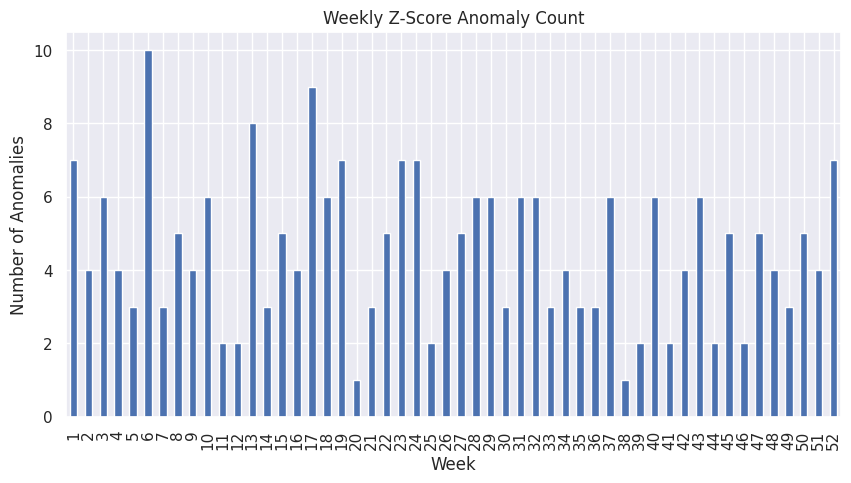

In [48]:
anomalies["Week"] = pd.to_datetime(anomalies["Date"]).dt.isocalendar().week
weekly_anomalies = anomalies.groupby("Week").size()
plt.figure(figsize=(10,5))
weekly_anomalies.plot(kind="bar")
plt.title("Weekly Z-Score Anomaly Count")
plt.xlabel("Week")
plt.ylabel("Number of Anomalies")
plt.show()